# **Post-COVID Conditions: Exploratory Data Analysis**
### CS 675 – Introduction to Data Science, Spring 2026  

## 1. Introduction & Dataset Overview

This project analyzes national survey data on post-COVID conditions in the United States. The dataset contains 18,639 observations and 16 variables, including measures of COVID infection history, Long COVID prevalence, activity limitations, and demographic subgroup breakdowns.

This exploratory analysis focuses on three questions:

1. How do national COVID and Long COVID prevalence measures compare?

2. How do activity limitations differ between adults with Long COVID and the overall adult population

3. Do Long COVID rates differ by race/ethnicity?

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/sarahcruz/Downloads/Post-COVID_Conditions.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (18639, 16)
Columns: ['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period', 'Time Period Label', 'Time Period Start Date', 'Time Period End Date', 'Value', 'LowCI', 'HighCI', 'Confidence Interval', 'Quartile range', 'Quartile number', 'Suppression Flag']


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile range,Quartile number,Suppression Flag
0,"Ever experienced long COVID, as a percentage o...",National Estimate,United States,United States,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,14.0,13.5,14.5,13.5 - 14.5,NaN,NaN,NaN
1,"Ever experienced long COVID, as a percentage o...",By Age,United States,18 - 29 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,17.8,15.9,19.8,15.9 - 19.8,NaN,NaN,NaN
2,"Ever experienced long COVID, as a percentage o...",By Age,United States,30 - 39 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,15.2,14.1,16.2,14.1 - 16.2,NaN,NaN,NaN
3,"Ever experienced long COVID, as a percentage o...",By Age,United States,40 - 49 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,16.9,15.7,18.3,15.7 - 18.3,NaN,NaN,NaN
4,"Ever experienced long COVID, as a percentage o...",By Age,United States,50 - 59 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,15.3,14.1,16.7,14.1 - 16.7,NaN,NaN,NaN


## 2. Data Preparation

In [39]:
# Standardize Column Names 
df.columns = df.columns.str.strip()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Convert Key Variables to Appropriate Data Types
df["Time Period Start Date"] = pd.to_datetime(df["Time Period Start Date"], errors="coerce")
df["Time Period End Date"] = pd.to_datetime(df["Time Period End Date"], errors="coerce")

# Missing Value Assesment 
print("Missing Values Summary:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nPercent Missing:")
print((df.isnull().mean()*100).sort_values(ascending=False).round(2))

Missing Values Summary:
Suppression Flag          16807
Quartile number            6862
Quartile range             6859
Value                      2453
LowCI                      2453
HighCI                     2453
Confidence Interval        2453
Indicator                     0
Group                         0
State                         0
Subgroup                      0
Phase                         0
Time Period                   0
Time Period Label             0
Time Period Start Date        0
Time Period End Date          0
dtype: int64

Percent Missing:
Suppression Flag          90.17
Quartile number           36.82
Quartile range            36.80
Value                     13.16
LowCI                     13.16
HighCI                    13.16
Confidence Interval       13.16
Indicator                  0.00
Group                      0.00
State                      0.00
Subgroup                   0.00
Phase                      0.00
Time Period                0.00
Time Period Label

## 3. Distribution & Variability Assessment

In [40]:
print("Summary Statistics for Numerical Variables:")
print(df[["Value", "LowCI", "HighCI"]].describe())

Summary Statistics for Numerical Variables:
              Value         LowCI        HighCI
count  16186.000000  16186.000000  16186.000000
mean      22.978111     19.675516     26.588855
std       22.475114     20.853023     23.909894
min        0.000000      0.000000      0.500000
25%        5.900000      4.400000      7.700000
50%       14.700000     11.400000     18.100000
75%       31.300000     26.500000     38.300000
max       92.800000     90.300000     95.400000


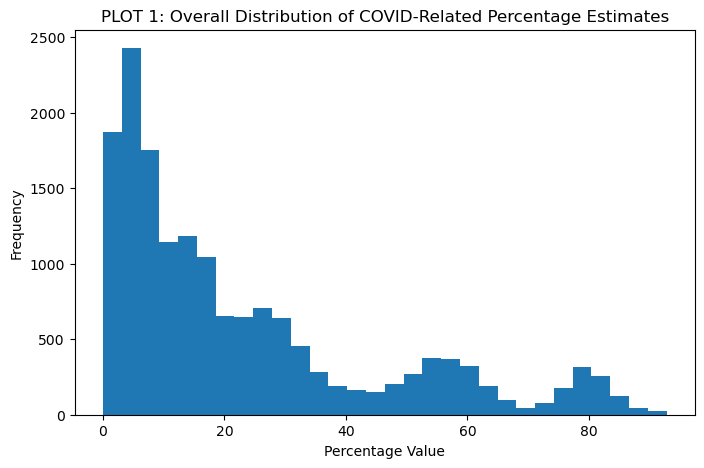

In [55]:
plt.figure(figsize=(8,5))
plt.hist(df["Value"].dropna(), bins=30)
plt.xlabel("Percentage Value")
plt.ylabel("Frequency")
plt.title("PLOT 1: Overall Distribution of COVID-Related Percentage Estimates")
plt.show()

PLOT 1: The distribution of percentage estimates is right-skewed, with the majority of values clustered below 30%. This illustrates that most COVID-related indicators, such as current Long COVID prevalence across demographic groups, affect a relatively small share of the total adult population. However, when looking at the higher-percentage values (ranging from 50% to over 80%) there are multiple clusters which correspond to measures with different denominators, such as “ever had COVID” or activity limitations among individuals already experiencing Long COVID. This suggests that the dataset combines indicators measured at different population levels, resulting in substantial overall variability.

### Boxplot for Outlier Detection

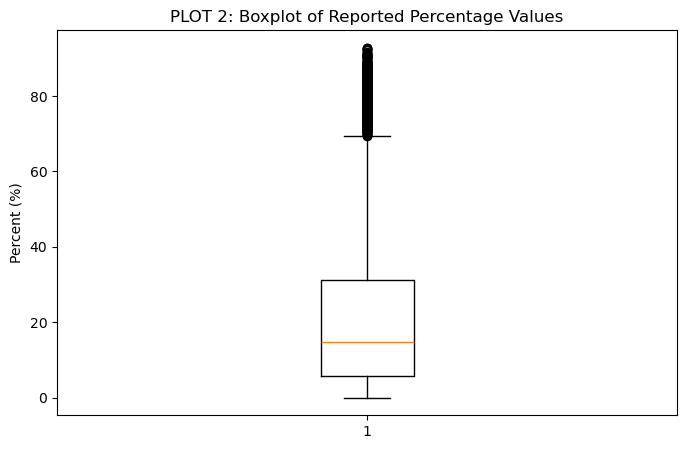

In [56]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Value"].dropna())
plt.ylabel("Percent (%)")
plt.title("PLOT 2: Boxplot of Reported Percentage Values")
plt.show()

PLOT 2: The boxplot reveals significant variability in reported percentage values. While most estimates fall below 30%, shown by the median at 14% and Q3 at about 30%, a cluster of higher values above 70% appears as statistical outliers. These high values are not data errors but correspond to indicators measured among specific subpopulations (e.g., individuals currently experiencing Long COVID), where percentages are naturally higher due to different denominators.

## 4. Latest Time Period Filtering

In [43]:
latest_time = df["Time Period"].max()
latest_df = df[df["Time Period"] == latest_time].copy()

print("Latest Time Period:", latest_time)
print("Latest_df shape:", latest_df.shape)

Latest Time Period: 72
Latest_df shape: (702, 16)


For consistant comparisons across indicators, the dataset was filtered to include only the most recent survey period.

## 5. Research Questions

## **Question 1: How do national COVID and long COVID prevalence measures compare?**

In [44]:
q1 = latest_df[
    (latest_df["Group"] == "National Estimate") &
    (latest_df["State"] == "United States") &
    (
        (latest_df["Indicator"].str.contains("Ever had COVID", case=False, na=False)) |
(latest_df["Indicator"].str.contains("Ever experienced long COVID, as a percentage of all adults", case=False, na=False)) |
(latest_df["Indicator"].str.contains("Currently experiencing long COVID, as a percentage of all adults", case=False, na=False))
    )
][["Indicator", "Value"]].dropna().sort_values("Value", ascending=False)

print(q1)

                                               Indicator  Value
18249                                     Ever had COVID   61.6
18015  Ever experienced long COVID, as a percentage o...   29.8
17937  Ever experienced long COVID, as a percentage o...   17.9
18171  Currently experiencing long COVID, as a percen...    8.7
18093  Currently experiencing long COVID, as a percen...    5.3


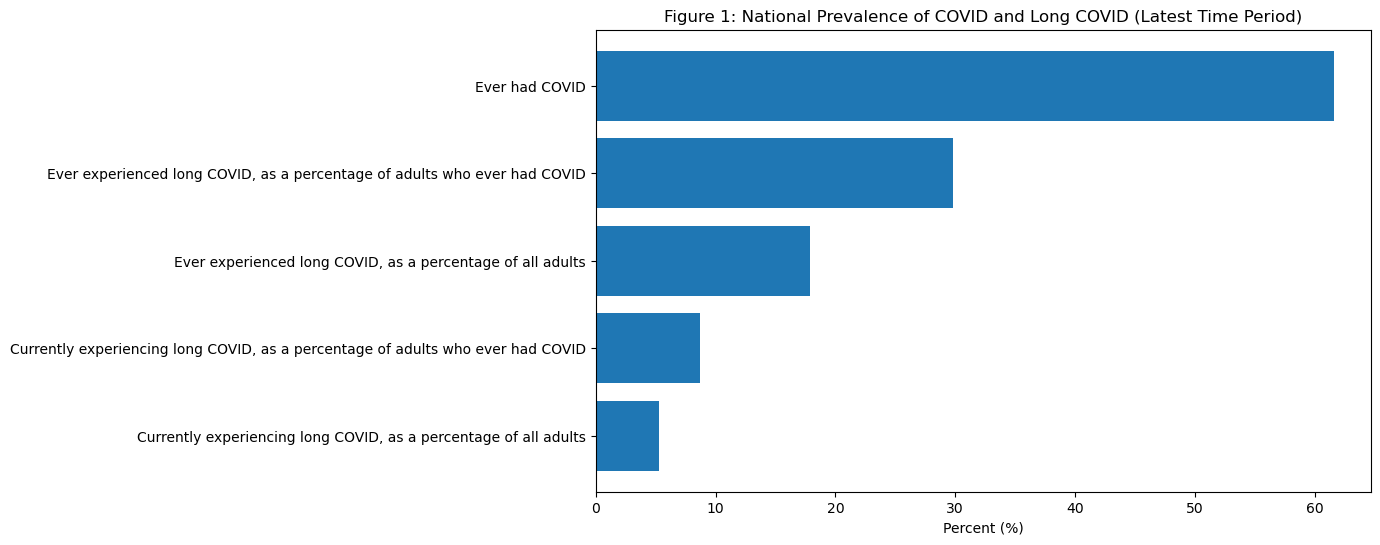

In [52]:
plt.figure(figsize=(10,6))
plt.barh(q1["Indicator"], q1["Value"])
plt.xlabel("Percent (%)")
plt.title("Figure 1: National Prevalence of COVID and Long COVID (Latest Time Period)")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

National prevalence estimates illustrate a clear progression. A majority of adults report having ever had COVID, a smaller percentage report ever experiencing long COVID, and an even smaller percentage report currently experiencing long COVID.

This pattern suggests that although rouhgly 65% of people are represented to have had COVID in this report, long COVID affects a smaller subset of individuals. Persistent symptoms are even less common than prior infection or prior long COVID experience. These estimates use different denominators (ex: all adults vs. adults who have Long COVID), so direct comparisons should be interpreted with that in mind.

## **Question 2: How do activity limitations differ between adults with long COVID and the overall adult population?**

In [46]:
q2 = latest_df[
    (latest_df["Group"] == "National Estimate") &
    (latest_df["State"] == "United States") &
    (latest_df["Indicator"].str.contains("activity limitations", case=False, na=False))
][["Indicator", "Value"]].dropna().sort_values("Value", ascending=False)

print(q2)

                                               Indicator  Value
18327  Any activity limitations from long COVID, as a...   80.1
18483  Significant activity limitations from long COV...   24.3
18405  Any activity limitations from long COVID, as a...    4.4
18561  Significant activity limitations from long COV...    1.3


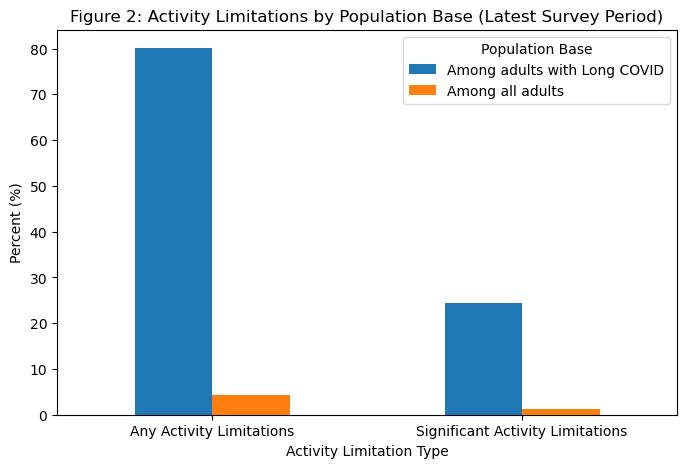

In [53]:
q2_multi = latest_df[
    (latest_df["Group"] == "National Estimate") &
    (latest_df["State"] == "United States") &
    (latest_df["Indicator"].str.contains("activity limitations", case=False, na=False))
][["Indicator", "Value"]].dropna().copy()


q2_multi["Population Base"] = q2_multi["Indicator"].apply(
    lambda x: "Among adults with Long COVID"
    if "currently have long COVID" in x
    else "Among all adults"
)

q2_multi["Limitation Type"] = q2_multi["Indicator"].apply(
    lambda x: "Any Activity Limitations"
    if "Any activity limitations" in x
    else "Significant Activity Limitations"
)

pivot_q2_multi = q2_multi.pivot(
    index="Limitation Type",
    columns="Population Base",
    values="Value"
)

pivot_q2_multi.plot(kind="bar", figsize=(8,5))

plt.ylabel("Percent (%)")
plt.xlabel("Activity Limitation Type")
plt.title("Figure 2: Activity Limitations by Population Base (Latest Survey Period)")
plt.xticks(rotation=0)
plt.legend(title="Population Base")
plt.show()

### Interpretation

The results show a substantial difference in reported activity limitations depending on the population being examined. Among adults currently experiencing Long COVID, 80.1% report some level of activity limitation and 24.3% report significant limitations. In contrast, when measured relative to the entire adult population, these values drop to 4.4% and 1.3%, respectively.

This difference occurs because the measures use different denominators. Estimates calculated among individuals with Long COVID reflect the severity of limitations within the affected subgroup, whereas estimates calculated among all adults represent the overall population-level prevalence. As a result, activity limitations appear much more pronounced when examining individuals currently experiencing Long COVID. These findings highlight how denominator choice can strongly influence the interpretation of percentage-based public health measures.

## **Question 3: Do long COVID rates differ by race/ethnicity?**

In [48]:
q3 = latest_df[
    (latest_df["Group"] == "By Race/Hispanic ethnicity") &
    (latest_df["State"] == "United States") &
    (latest_df["Indicator"] == "Currently experiencing long COVID, as a percentage of all adults")
][["Subgroup","Value"]].dropna().sort_values("Value", ascending=False)

print(q3)

                                           Subgroup  Value
18113  Non-Hispanic, other races and multiple races    7.3
18110               Non-Hispanic White, single race    5.7
18109                            Hispanic or Latino    4.5
18111               Non-Hispanic Black, single race    4.4
18112               Non-Hispanic Asian, single race    2.8


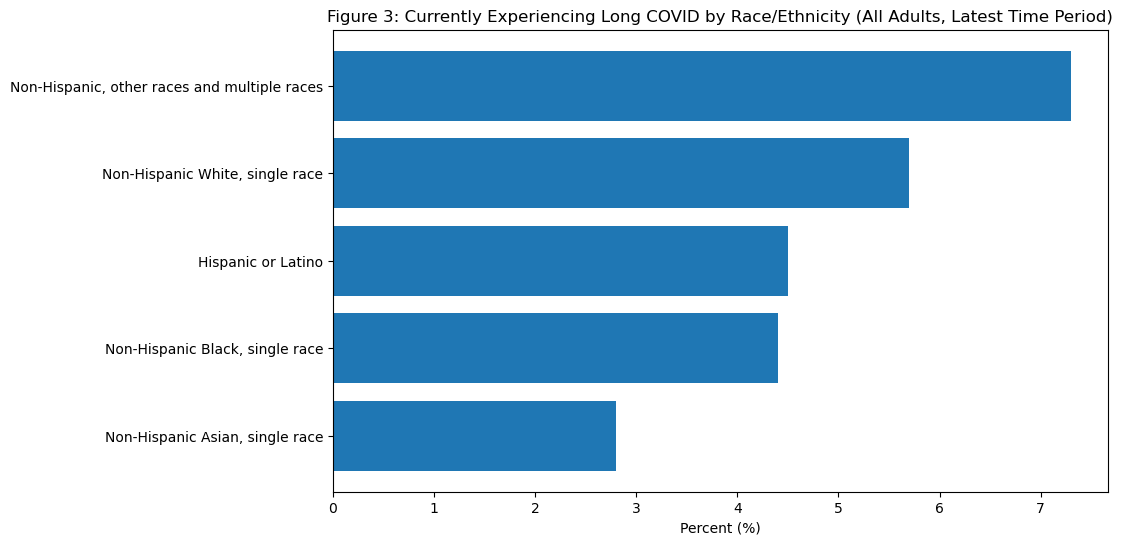

In [54]:
plt.figure(figsize=(10,6))
plt.barh(q3["Subgroup"], q3["Value"])
plt.xlabel("Percent (%)")
plt.title("Figure 3: Currently Experiencing Long COVID by Race/Ethnicity (All Adults, Latest Time Period)")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

Long COVID prevalence differs across racial and ethnic groups in the most recent survey period. The highest reported percentage appears among individuals identifying as Non-Hispanic, other races and multiple races (7.3%), while the lowest appears among Non-Hispanic Asian adults (2.8%). 

Although the overall prevalence remains below 10% for all groups, the difference between the highest and lowest groups is about 4% providing a noticeable gap. 

## Summary of Key Findings (Descriptive Analysis – Latest Survey Period)

In [50]:
summary_table = pd.DataFrame({
    "Metric": [
        "Highest Prevalence (COVID vs Long COVID)",
        "Any Activity Limitations (Adults with Long COVID)",
        "Any Activity Limitations (All Adults)",
        "Significant Activity Limitations (Adults with Long COVID)",
        "Significant Activity Limitations (All Adults)",
        "Race/Ethnicity with Highest Current Long COVID Prevalence",
        "Race/Ethnicity with Lowest Current Long COVID Prevalence"
    ],

    "Group / Indicator": [
        q1.iloc[0]["Indicator"],

        q2.iloc[0]["Indicator"],   # Any limitations (Long COVID)
        q2.iloc[2]["Indicator"],   # Any limitations (All adults)

        q2.iloc[1]["Indicator"],   # Significant limitations (Long COVID)
        q2.iloc[3]["Indicator"],   # Significant limitations (All adults)

        q3.iloc[0]["Subgroup"],    # Highest race value
        q3.iloc[-1]["Subgroup"]    # Lowest race value
    ],

    "Value (%)": [
        q1.iloc[0]["Value"],

        q2.iloc[0]["Value"],
        q2.iloc[2]["Value"],

        q2.iloc[1]["Value"],
        q2.iloc[3]["Value"],

        q3.iloc[0]["Value"],
        q3.iloc[-1]["Value"]
    ]
})

summary_table

,Metric,Group / Indicator,Value (%)
0,Highest Prevalence (COVID vs Long COVID),Ever had COVID,61.6
1,Any Activity Limitations (Adults with Long COVID),"Any activity limitations from long COVID, as a...",80.1
2,Any Activity Limitations (All Adults),"Any activity limitations from long COVID, as a...",4.4
3,Significant Activity Limitations (Adults with ...,Significant activity limitations from long COV...,24.3
4,Significant Activity Limitations (All Adults),Significant activity limitations from long COV...,1.3
5,Race/Ethnicity with Highest Current Long COVID...,"Non-Hispanic, other races and multiple races",7.3
6,Race/Ethnicity with Lowest Current Long COVID ...,"Non-Hispanic Asian, single race",2.8


This table summarizes the most important descriptive findings from the latest survey period. 

## Limitations

There are meaningful limitations seen throughout this dataset. The data values were self-reported, allowing for the possibility of bias. Some individuals may interpret their symptoms differently, which may lead to varying meanings of symptoms. Additionally, since the data compared different populations which had different denominators, it can be difficult when comparisons are made between them. There were also missing values within the dataset, which could potentially impact the results. 

To improve future analysis, the dataset should include socioeconomic status and severity of the infections. I believe that these indicators would provide insightful comparisons to allow for meaningful change in the healthcare sector. 

This exploratory data analysis was created to make observations between indicators. There are no causal claims being made. Therefore, the patterns found within this dataset are not applicable to cause-and-effect relationships.


## Conclusion

Overall, this exploratory data analysis found that Long COVID affects a small subset of those who had COVID. While the prevalence of Long COVID is low, those who have it are impacted by limitations. The races/ethnicities impacted most are Non-Hispanic, other races and multiple races, and the least are Non-Hispanic Asian adults. Although Long COVID affects a small portion of the population, the impacts are meaningful and deserve proper acknowledgement for future research. 